### Projet d'optimisation de Pauline Normant et Inès Gabillé

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import casadi as ca 

#### Partie I - Etude du problème d'optimisation

***Question 1 :  Justifier la forme de la dynamique de charge***

Considérons la charge du véhicule j :  

Au temps i+1, la charge du véhicule est celle du temps i + la charge entre l'instant i et i+1:
$Q_{i+1} = Q_{i} + \Delta Q_{i,i+1}$  

La charge entre l'instant i et i+1 correspond à l'énergie apporté pendant l'instant $\Delta t$ suivant une certaine caractéristique de la voiture, qu'on nomme $\beta$ qui prend en compte des informations comme le rendement.  
Ainsi, $\Delta Q_{i,i+1} = \beta \Delta t P_i$.  

Ainsi, pour une voiture, $Q_{i+1} = Q_{i} + \beta \Delta t P_i$   

Donc pour une voiture j, $Q_{j,i+1} = Q_{j,i} + \beta \Delta t P_{j,i}$  


***Question 2 : Formuler le problème d’optimisation à résoudre. On précisera les variables de décision x, leur nombre n, les contraintes ceq et cin ainsi que la fonction objectif f à minimiser.***

Notre problème peut se mettre sous la forme :  

$min_x f(x)$  
tel que $c_{eq}(x) = 0$  
        $c_{in}(x) \leq 0$  


Avec:  
$f(x) = \Delta t \sum_{j=1}^{N_V} \sum_{i=0}^N c_i x_{j,i}$  avec  $x_{i,j} = (P_{i,j}, Q_{i,j})$

$c_{eq1} : \forall j \in \{ 1,...,N_V \}, \forall i \in \{ 0,....,N \}, \forall t_i \notin [t_n^{in},t_j^{f}], P_{j,i} = 0$  
$c_{eq2} : \forall j \in \{ 1,...,N_V \}, \forall i \in \{ 0,....,N \}, Q_{j,i+1} - Q_{j,i} - \beta \Delta t P_{j,i} = 0$  
$c_{eq3} : \forall j \in \{ 1,...,N_V \}, Q_{j,i_{j0}} - Q_j^{in} = 0$ avec $i_{j0} = \frac{t_j^{in}}{\Delta t}$  
$c_{eq4} : \forall j \in \{ 1,...,N_V \}, Q_{j,i_{jf}} - \overline{Q_j} = 0$ avec $i_{jf} = \frac{t_j^{f}}{\Delta t}$  

$c_{in1} : \forall i \in \{ 0,....,N \}, \sum_{j=1}^{N_v} P_{j,i} - \overline{P} \leq 0$  
$c_{in2} : \forall j \in \{ 1,...,N_V \}, \forall i \in \{ 0,....,N \}, -P_{j,i} \leq 0$

Ainsi, les variables de décisions sont au nombre de $n = 2 \times N_V \times N$, car elles correspondent aux coupes $(P_{i,j}, Q_{i,j})$.

***Question 3 : Etudier la convexité de ce problème. Appartient-il à une famille particulière de problèmes d’optimisation?***

Pour qu'un problème soit convexe, la fonction f à minimiser doit être convexe, ainsi que les contraintes égalités doivent être affines et les contraintes inégalités doivent être convexes. Dans notre cas, la fonction f a minimiser est linéaire, donc convexe, et toutes les contraintes égalités sont affines, et les contraintes inégalités sont linéaires donc convexes.  
Ainsi, notre problème est bien convexe. Il est même linéaire (toutes les contraintes sont linéaires et f est linéaire), donc appartient à la famille des problèmes linéaires.

#### Partie II - Identification du paramètre $\beta$

***Question 4 :  On cherche à identifier le paramètre $\beta$ à partir de ces essais, connaissant la charge maximale atteignable $\overline{Q}$ (qui est elle simple à déterminer) et la tension secteur $U_{sec} = 230V$ , reliant puissance et intensité.
Formuler le problème de moindres carrés correspondant à l’identification de $\beta$.***

Nous pouvons considéré un seul véhicule car ils ont tous la même charge maximale et le même $\beta$.

On a $\forall i \in [0; N-1], Q_{i+1} = Q_i + \Delta t\beta P_i$

Ainsi : $\forall i \in [0; N-1], \beta P_i = (SOC_{i+1}-SOC_i)Q_{barre}/\Delta t$ qui va constituer notre problème des moindres carrés. 

***Question 5 : Charger les données à l’aide du fichier data_battery.csv et résoudre ce problème pour $\overline{Q} = 50Ah$. On pourra utiliser la solution des moindres carrés, ou utiliser la fonction numpy.linalg.lstsq. On n’oubliera pas de filtrer convenablement le bruit de mesure, si besoin, et de commenter l’impact de ce filtrage sur les résultats obtenus. On tracera en particulier sur la même figure l’évolution de l’état de charge de la batterie au cours du temps, ainsi que l’état de charge estimé obtenu à partir de l’intensitéet du paramètre estimé $\beta$.***

On veut résoudre Ax = b avec A qui est la matrice des puissances

La valeur de beta trouvé pour les données brutes est : 0.002982908229641423


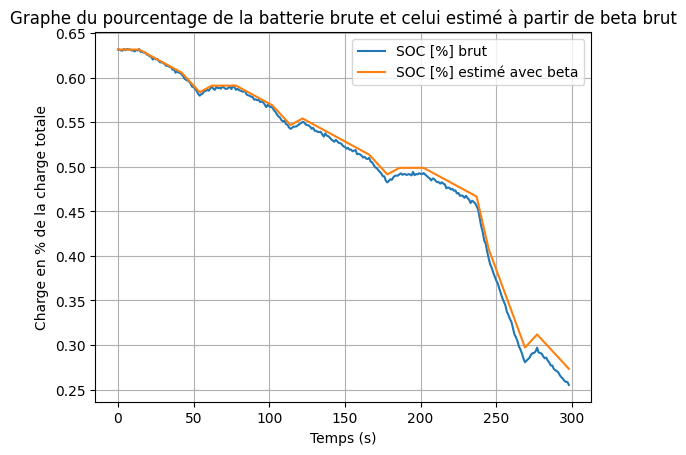

In [17]:
#Question 5
U_sec = 230
Q_barre = 50*3600

data = pd.read_csv("data_battery.csv")
N = len(data)

time = np.array(data["Time [s]"])
list_A = np.array(1000*U_sec*data["I [kA]"]) 
A = list_A[:N-1]
A = A.reshape((N-1, 1))

SOC = np.array(data["SOC [%]"])
b = (SOC[1:]-SOC[:N-1])*Q_barre/(time[1:]-time[:N-1])
b = b.reshape((N-1,1))

#Pour le problème des moindres carrés, on peut prendre la solution explicite : Beta = (A^T*A)^{-1}*(A^T*b) ou utiliser la fonction np.linalg.lstsq pour résoudre Ax = b
sol = np.linalg.lstsq(A, b) #sol[0] = beta ; sol[1] = somme des résidus ; sol[2] = rang de la matrice A ; sol[3] = valeur singulière de A
beta = sol[0][0][0]

print("La valeur de beta trouvé pour les données brutes est :", beta)

#Estimation de la charge de la batterie à partir de la valeur Beta

#initialisation
SOC_estime = np.zeros(N)
SOC_estime[0] = data["SOC [%]"].iloc[0]

#Récurrence
for i in range(1, N):
    SOC_estime[i]=SOC_estime[i-1] + (time[i]-time[i-1])*beta*list_A[i]/Q_barre

#Affichage du graphe de la batterie
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = 5, on = data.index).mean()
data['SOC [%] estimé avec beta'] = SOC_estime
data[['SOC [%] brut', 'SOC [%] estimé avec beta']].plot(title = "Graphe du pourcentage de la batterie brute et celui estimé à partir de beta brut")
plt.xlabel("Temps (s)")
plt.ylabel("Charge en % de la charge totale")
plt.grid()
plt.show()

La valeur de beta trouvé pour les données brut est : 2.982908229641423

La valeur de beta trouvé pour les données lissées est : 0.002618604830899051


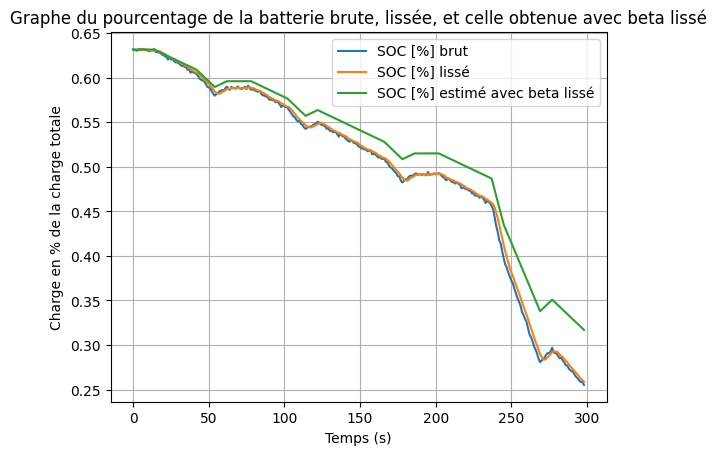

In [16]:
#Question 5
U_sec = 230
Q_barre = 50*3600
window = 5

data = pd.read_csv("data_battery.csv")
data['SOC [%] lissé'] = data["SOC [%]"].rolling(window = window).mean()
N = len(data)

time = np.array(data["Time [s]"])
list_A = np.array(1000*U_sec*data["I [kA]"]) 
A = list_A[:N-window]
A = A.reshape((N-window, 1))

SOC_lisse = np.array(data["SOC [%] lissé"])
b_lisse = (SOC_lisse[window:]-SOC_lisse[window-1:N-1])*Q_barre/(time[window:]-time[window-1:N-1])
b_lisse = b_lisse.reshape((N-window,1))

#Pour le problème des moindres carrés, on peut prendre la solution explicite : Beta = (A^T*A)^{-1}*(A^T*b) ou utiliser la fonction np.linalg.lstsq pour résoudre Ax = b
sol_lisse = np.linalg.lstsq(A, b_lisse) #sol[0] = beta ; sol[1] = somme des résidus ; sol[2] = rang de la matrice A ; sol[3] = valeur singulière de A
beta_lisse = sol_lisse[0][0][0]

print("La valeur de beta trouvé pour les données lissées est :", beta_lisse)

#Estimation de la charge de la batterie à partir de la valeur Beta

#initialisation
SOC_estime_lisse = np.zeros(N)
SOC_estime_lisse[0] = data["SOC [%]"].iloc[0]

#Récurrence
for i in range(1, N):
    SOC_estime_lisse[i]=SOC_estime_lisse[i-1] + (time[i]-time[i-1])*beta_lisse*list_A[i]/Q_barre

#Affichage du graphe de la batterie
data["SOC [%] brut"] = data["SOC [%]"]
data['SOC [%] estimé avec beta lissé'] = SOC_estime_lisse
data[['SOC [%] brut', 'SOC [%] lissé', 'SOC [%] estimé avec beta lissé']].plot(title = "Graphe du pourcentage de la batterie brute, lissée, et celle obtenue avec beta lissé")
plt.xlabel("Temps (s)")
plt.ylabel("Charge en % de la charge totale")
plt.grid()
plt.show()

##### Partie III - Etude et résolution numérique du problème centralisé  

***Question 6 : Quelles méthodes de résolution peuvent être envisagées pour ce problème?***

Nous avons un problème de minimisation linéaire sous contraintes, on peut donc utiliser la méthode de résolution IpOpt de Casadi (résolution numérique) pour résoudre notre problème.

***Question 7 : Développer un algorithme de résolution dans le cas d’un horizon de temps de 24h (t0 = 17h, ∆t =0.25h)***

In [7]:
#Les données sont les suivantes : 

ccr = 1 #tarif heure creuse
cpl = 3/2 #tarif heure plein
t0 = 17 #on initialise à 17h
dt = 900 #0,25h en seconde
minuit = 8*4
six_h = minuit + 6*4
douze_h = minuit + 12*4
quat_h = minuit + 14*4
Q_barre = 50*3600 #A.s
P_barre =2.5*1000 #W
n_vehicule = 2
T = 24*4
H_arr = np.array([4,6]) #nombre de dt à partir de 17h
H_dep = np.array([64,68]) #nombre de dt à partir de 17h
SOC_ini = np.array([0.3,0.5]) #état de charge à l'arrivée

In [8]:
#list des coûts en fonction de l'heure de la journée
prix = []
for i in range(T) :
    if i < minuit or (i> six_h and i< douze_h) or i> quat_h :
        prix.append(cpl)
    else : 
        prix.append(ccr)

prix = ca.SX([prix,prix])

In [9]:
P = ca.SX.sym('P', n_vehicule, T)
Q = ca.SX.sym('Q', n_vehicule, T)

x = ca.vertcat( 
    ca.reshape(P, n_vehicule*T,1),
    ca.reshape(Q,n_vehicule*T,1)
)

#objective 
cost =dt*ca.sum(prix*P)



In [10]:
beta = beta_lisse

lbx = []
ubx = []

#Bounds on P
lbx += [0]*(n_vehicule*T)
ubx += [P_barre]*(n_vehicule*T)

#Bounds on Q (Q entre 0 and Q_barre)
lbx += [0]*(n_vehicule*T)
ubx += [Q_barre]*(n_vehicule*T)

g = []
lbg = []
ubg = []

#Contrainte ceq1 :
for j in range(n_vehicule):
    for k in range(H_arr[j]):
        g.append(P[j,k])
        lbg.append(0.0)
        ubg.append(0.0)
    for k in range(T-H_dep[j]):
        g.append(P[j, T-k-1])
        lbg.append(0.0)
        ubg.append(0.0)

#Contrainte ceq2 : Qj,i+1 - Qj,i -beta*delta_t*Pj,i = 0
for j in range(n_vehicule):
    for i in range(T-1):
        g.append(Q[j, i+1] - Q[j, i] - (beta * dt) * P[j, i])
        lbg.append(0.0)
        ubg.append(0.0)

#Contrainte ceq3 : 
for j in range(n_vehicule):
    g.append(Q[j,H_arr[j]]-SOC_ini[j]*Q_barre)
    lbg.append(0.0)
    ubg.append(0.0)

#Contrainte ceq4 :
for j in range(n_vehicule):
    g.append(Q[j,H_dep[j]]-Q_barre) #Il faut qu'ils soit chargé à 100% à la fin
    lbg.append(0.0)
    ubg.append(0.0)

#Contrainte cin1 : 

#Contrainte cin2 :
for i in range(T):
    g.append(ca.sum(P[:,i]))
    lbg.append(0.0)
    ubg.append(P_barre)

In [11]:
#Convertir les contraintes en vecteur
g_vec = ca.vertcat(*g)

nlp = {'x':x, 'f': cost, 'g': g_vec}
solver = ca.nlpsol('s', 'ipopt', nlp)

sol = solver(
    x0 = np.ones(2*n_vehicule*T),
    lbx = np.array(lbx),
    ubx = np.array(ubx),
    lbg = np.array(lbg),
    ubg = np.array(ubg),
)
res = sol['x']
P_sol = sol['x'][:n_vehicule*T]
Q_sol = sol['x'][n_vehicule*T:]

P_sol = ca.reshape(P_sol, n_vehicule, T)
Q_sol =  ca.reshape(Q_sol, n_vehicule, T)

Q_sol


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      644
Number of nonzeros in inequality constraint Jacobian.:      192
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:      384
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      384
                     variables with only upper bounds:        0
Total number of equality constraints.................:      264
Total number of inequality c

DM(
[[54000, 54000, 54000, 54000, 54000, 55201.4, 56396, 57343.9, 58285.8, 59222, 60152.6, 61078, 61998.4, 62913.9, 63824.9, 64731.4, 65633.7, 66532.1, 67426.5, 68317.3, 69204.6, 70088.5, 70969.2, 71846.9, 72721.6, 73593.6, 74462.9, 75329.8, 76194.2, 77056.3, 77916.4, 78774.3, 79630.4, 83305.2, 86968, 90619.3, 94259.4, 97888.5, 101507, 105115, 108713, 112301, 115880, 119448, 123008, 126557, 130098, 133630, 137153, 140667, 144175, 147675, 151169, 154659, 158148, 161640, 165142, 168665, 169775, 170960, 172242, 173664, 175296, 177270, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000, 180000], 
 [90000, 90000, 90000, 90000, 90000, 90000, 90000, 90622.9, 91246.7, 91871.5, 92497.4, 93124.2, 93752.1, 94381, 95011, 95642.2, 96274.4, 96907.9, 97542.5, 98178.4, 98815.6, 99454.1, 100094, 100735, 101378

Remarque : pour les graphes, les données sont affichées à partir de l'heure $T_0 = 17$ h.

***Graphique (a) : l’évolution de l’état de charge de chaque véhicule au cours du temps ainsi que la puissance (normalisée) fournie à chaque véhicule.***

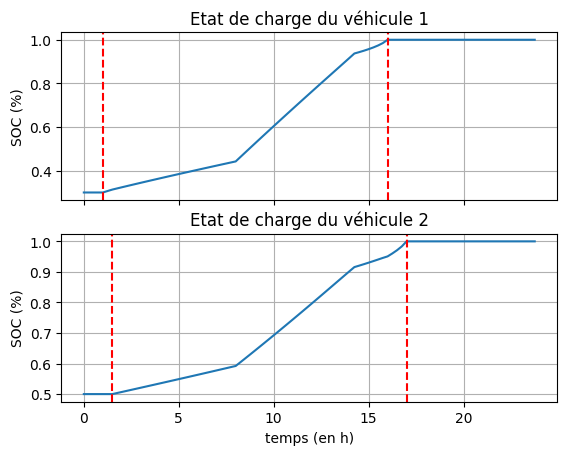

In [ ]:
#Evolution de l'état de charge

SOC = Q_sol/Q_barre
time = np.arange(T)/4 #temps en heure
fig, ax = plt.subplots(2, sharex = True)

#véhicule 1
ax[0].grid()
ax[0].plot(time, SOC[::2])
ax[0].set_title("Etat de charge du véhicule 1")
ax[0].set_ylabel("SOC (%)")
ax[0].axvline(x= H_arr[0]/4, color='red', linestyle='--', label="Heure d'arrivée")
ax[0].axvline(x= H_dep[0]/4, color='red', linestyle='--', label="Heure de départ")

#véhicule 2
ax[1].grid()
ax[1].plot(time, SOC[1::2])
ax[1].set_title("Etat de charge du véhicule 2")
ax[1].set_xlabel("temps (en h)")
ax[1].set_ylabel("SOC (%)")
ax[1].axvline(x= H_arr[1]/4, color='red', linestyle='--', label="Heure d'arrivée")
ax[1].axvline(x= H_dep[1]/4, color='red', linestyle='--', label="Heure de départ")



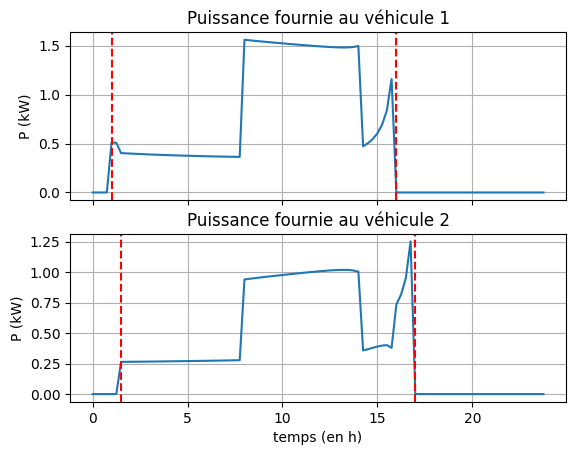

In [13]:
#Puissance normalisée fournie à chaque véhicule

time = np.arange(T)/4 #temps en heure
fig, ax = plt.subplots(2, sharex = True)

#véhicule 1
ax[0].grid()
ax[0].plot(time, P_sol[::2]/1000)
ax[0].set_title("Puissance fournie au véhicule 1")
ax[0].set_ylabel("P (kW)")
ax[0].axvline(x= H_arr[0]/4, color='red', linestyle='--', label="Heure d'arrivée")
ax[0].axvline(x= H_dep[0]/4, color='red', linestyle='--', label="Heure de départ")

#véhicule 2
ax[1].grid()
ax[1].plot(time, P_sol[1::2]/1000)
ax[1].set_title("Puissance fournie au véhicule 2")
ax[1].set_ylabel("P (kW)")
ax[1].set_xlabel("temps (en h)")
ax[1].axvline(x= H_arr[1]/4, color='red', linestyle='--', label="Heure d'arrivée")
ax[1].axvline(x= H_dep[1]/4, color='red', linestyle='--', label="Heure de départ")


***Graphique (b) : l’évolution de la puissance totale (normalisée) fournie à la flotte, au cours du temps, ainsi que celle du tarif électrique.***

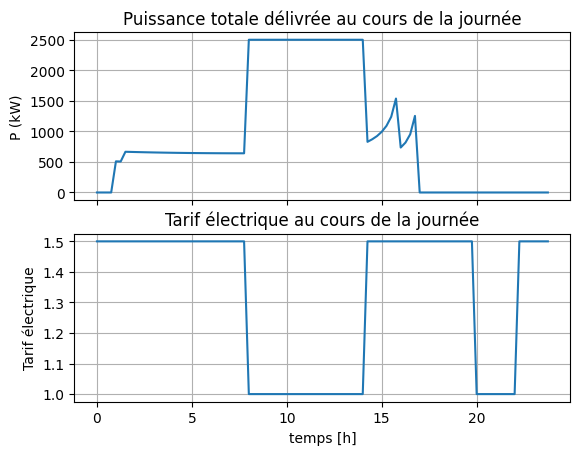

In [23]:
prix = []
for i in range(T) :
    if i < minuit or (i> six_h and i< douze_h) or i> quat_h :
        prix.append(cpl)
    else : 
        prix.append(ccr)

P_tot = np.array(P_sol[0,:]).reshape(T)+np.array(P_sol[1,:]).reshape(T)
temps = np.arange(T)/4
Prix = np.array(prix)

fig, ax = plt.subplots(2, sharex=True)
ax[0].plot(temps, P_tot)
ax[0].set_ylabel('P (kW)')
ax[0].grid()
ax[0].set_title("Puissance totale délivrée au cours de la journée")

ax[1].plot(temps, Prix)
ax[1].set_xlabel('temps [h]')
ax[1].set_ylabel('Tarif électrique')
ax[1].set_title("Tarif électrique au cours de la journée")
ax[1].grid()

***Question 8 : Quels inconvénients présente cette solution centralisée?***

Le problème ici est que l'on ne sait pas à l'avance à quelle heure veulent repartir les clients. Il faut donc commencer à charger dès le début.
De même, il y a peu de chance que toutes les batteries aient la même charge finale et l'optimiseur ne peut pas avoir accès à cette information. 